In [24]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [25]:
import zipfile
import os

# Drive mein file ka rasta (path)
zip_path = '/content/drive/MyDrive/train.zip'
# Extraction ki jagah
extract_path = '/content/dataset'

if os.path.exists(zip_path):
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_path)
    print("Extraction mukammal ho chuki hai!")
else:
    print("File nahi mili! Baraye meherbani path check karein.")

Extraction mukammal ho chuki hai!


In [27]:
# Folder structure check karna
base_dir = '/content/dataset'
folders = os.listdir(base_dir)
print(f"Folders found: {folders}")

Folders found: ['train']


In [29]:
import glob

def get_data_paths(base_path):
    # Maan lijiye folders ke naam 'cats' aur 'dogs' hain
    cats = glob.glob(os.path.join(base_path, '/content/dataset/train/cat/*.jpg'))
    dogs = glob.glob(os.path.join(base_path, '/content/dataset/train/dog/*.jpg'))

    # Cats ko 0 aur Dogs ko 1 label dete hain
    paths = cats + dogs
    labels = [0] * len(cats) + [1] * len(dogs)

    return paths, labels

# Extraction path se data uthana
image_paths, labels = get_data_paths('/content/dataset')
print(f"Total images: {len(image_paths)}")

Total images: 299


In [30]:
import torch.nn as nn
import torch.nn.functional as F
import torch

# Check karein agar GPU available hai to use karein, nahi to CPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Abhi hum '{device}' istemal kar rahe hain.")

class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()
        # Convolutional layers jo features extract karengi
        self.conv1 = nn.Conv2d(3, 16, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)

        # Fully connected layers classification ke liye
        self.fc1 = nn.Linear(32 * 56 * 56, 128)
        self.fc2 = nn.Linear(128, 2) # 2 outputs: Cat ya Dog

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = x.view(-1, 32 * 56 * 56) # Flattening the array [cite: 105]
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x

# Model instance banana aur GPU par move karna [cite: 106, 114]
model = SimpleCNN().to(device)
print("Model tayyar hai!")

Abhi hum 'cuda' istemal kar rahe hain.
Model tayyar hai!


In [32]:
import torch
from torch.utils.data import Dataset, DataLoader
import cv2
import numpy as np
import os
class PetDataset(Dataset):
    def __init__(self, paths, labels):
        self.paths = paths
        self.labels = labels

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        # OpenCV se image read karna
        img = cv2.imread(self.paths[idx])
        if img is None:
            # Agar koi image kharab ho to skip karne ke liye error handle karein
            return torch.zeros((3, 224, 224)), torch.tensor(self.labels[idx])

        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        # Resize image to 224x224
        img = cv2.resize(img, (224, 224))

        # NumPy array ko normalize aur Tensor mein convert karna (CHW format)
        img = img.transpose((2, 0, 1))
        img_tensor = torch.from_numpy(img).float() / 255.0

        label = torch.tensor(self.labels[idx])
        return img_tensor, label

In [55]:
import torch.optim as optim
from torch.utils.data import DataLoader

# 1. Pehle dataset object banayein (image_paths aur labels wahi hain jo humne pehle extract kiye)
dataset = PetDataset(image_paths,labels)

# 2. Ab DataLoader define karein
# batch_size=32 ka matlab hai aik waqt mein 32images process hongi
train_loader = DataLoader(dataset, batch_size=32, shuffle=True)

print("train_loader tayyar hai!")

# Loss function aur Optimizer define karein
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Training Loop
def train_model(epochs):
    model.train()
    for epoch in range(epochs):
        running_loss = 0.0
        for images, labels in train_loader:
            # Data ko GPU/CPU par bhejein
            images, labels = images.to(device), labels.to(device)

            # Gradients zero karein
            optimizer.zero_grad()

            # Forward pass
            outputs = model(images)
            loss = criterion(outputs, labels)

            # Backward pass aur optimize
            loss.backward()
            optimizer.step()

            running_loss += loss.item()

        print(f"Epoch {epoch+1}, Loss: {running_loss/len(train_loader)}")

# Training shuru karein (maslan 10 epochs ke liye)
train_model(10)

train_loader tayyar hai!
Epoch 1, Loss: 0.5992802560329438
Epoch 2, Loss: 0.5658234357833862
Epoch 3, Loss: 0.468777197599411
Epoch 4, Loss: 0.4636324420571327
Epoch 5, Loss: 0.3797064185142517
Epoch 6, Loss: 0.3033918008208275
Epoch 7, Loss: 0.2242110475897789
Epoch 8, Loss: 0.19035680145025252
Epoch 9, Loss: 0.1460958644747734
Epoch 10, Loss: 0.10515043511986732


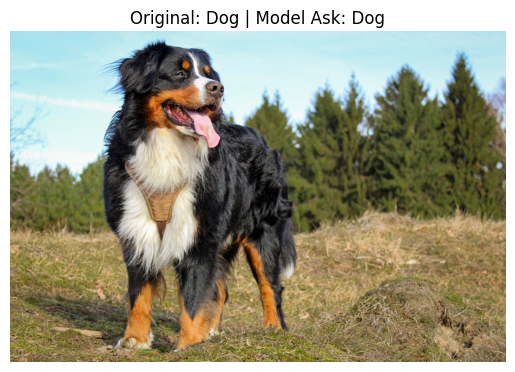

Congragulation. 


In [72]:
import matplotlib.pyplot as plt
import random

# Model ko evaluation mode par set karein
model.eval()

# Dataset se aik random image lein
idx = random.randint(0, len(image_paths)-1)
test_path = image_paths[idx]
true_label = "Dog" if labels[idx] == 1 else "Cat"

# Image ko process karein
img = cv2.imread(test_path)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
img_resized = cv2.resize(img_rgb, (224, 224))
img_tensor = torch.from_numpy(img_resized.transpose((2, 0, 1))).float().unsqueeze(0) / 255.0
img_tensor = img_tensor.to(device)

# Prediction
with torch.no_grad():
    output = model(img_tensor)
    _, predicted = torch.max(output, 1)
    pred_label = "Dog" if predicted.item() == 1 else "Cat"

# Result dikhayein
plt.imshow(img_rgb)
plt.title(f"Original: {true_label} | Model Ask: {pred_label}")
plt.axis('off')
plt.show()

if true_label == pred_label:
    print("Congragulation. ")
else:
    print("Oh! Misconception.")